In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
#AT => temperature
#V => vaccum
#AP=>pressure
#RH=> humidity

#PE=> produced energy

df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X= df.drop("PE", axis=1)
y = df["PE"]

In [6]:
#split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42
)

In [7]:
df.shape

(9568, 5)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [15]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)

y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)

In [16]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor) 

In [18]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

## Deep Learning

In [32]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [33]:
import torch.optim as optim

model = ANN()
#loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())


In [34]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 205601.02259114583 & val loss = 203406.359375
epoch 2/100 ==> train loss = 196628.14739583334 & val loss = 185472.328125
epoch 3/100 ==> train loss = 166323.47493489584 & val loss = 142506.078125
epoch 4/100 ==> train loss = 114384.77926432292 & val loss = 85625.171875
epoch 5/100 ==> train loss = 61706.27078450521 & val loss = 42277.91015625
epoch 6/100 ==> train loss = 31193.995654296876 & val loss = 24004.1953125
epoch 7/100 ==> train loss = 20248.32159423828 & val loss = 17939.49609375
epoch 8/100 ==> train loss = 15819.943111165365 & val loss = 14222.5478515625
epoch 9/100 ==> train loss = 12422.758502197266 & val loss = 10933.439453125
epoch 10/100 ==> train loss = 9388.49552001953 & val loss = 8022.70556640625
epoch 11/100 ==> train loss = 6746.050524902344 & val loss = 5623.599609375
epoch 12/100 ==> train loss = 4661.723599243164 & val loss = 3835.8837890625
epoch 13/100 ==> train loss = 3151.419542948405 & val loss = 2585.7099609375
epoch 14/100 =

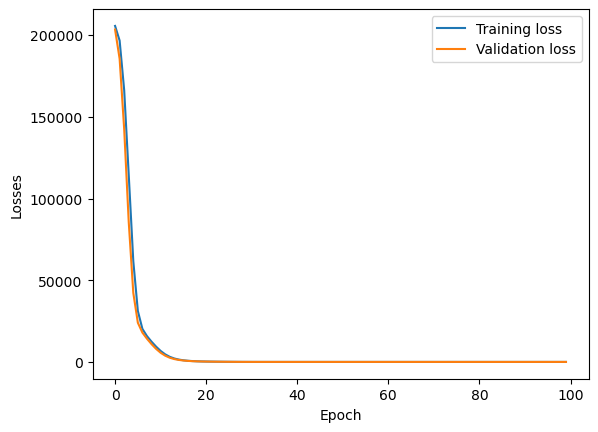

In [40]:
import matplotlib.pyplot as plt
loss_df =pd.DataFrame({
    "Training loss": train_losses,
    "Validation loss": val_losses

})

plt.plot(loss_df["Training loss"], label = "Training loss")
plt.plot(loss_df["Validation loss"], label = "Validation loss")


plt.xlabel("Epoch")
plt.ylabel("Losses")
plt.legend()

In [41]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [42]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 19.813791275024414
Testing MSE: 18.18697166442871


In [43]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9364412387378245


In [44]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.203979,433.27
1,436.651917,438.16
2,461.338898,458.42
3,476.413666,480.82
4,434.998810,441.41
...,...,...
1909,451.443817,456.70
1910,431.411041,438.04
1911,467.854218,467.80
1912,430.767426,437.14
